In [ ]:
#Step 1: Load,Explore and Preprocess
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
df=pd.read_csv("train.csv")
print("First few rows: ")
print(df.head())

print("\nDataset Shape:")
print(df.shape)
print("\nDataset Information:\n")
df.info()
print("\nMissing Values: \n")
print(df.isnull().sum())
df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop('Cabin',axis=1,inplace=True)
print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])
df['Embarked']=le.fit_transform(df['Embarked'])
print("\nEncoded Columns Successfully")
print("\nEncoded Dataset Preview\n")
print(df.head())
X=df.drop(['Survived'],axis=1)
y=df['Survived']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)
print("Training Set:",X_train.shape)
print("Testing Set",X_test.shape)

# Step 1: Load,Explore and Preprocess the dataset
The Titanic dataset was loaded using Pandas and explored using head(),shape() and info() to understand its structure,size,and data types.Missing values were identified using isnull(),sum().

The **Age** columns contained 177 missing values,which were replaced with the median because its a numericaL feature and median is less affected by outliers.

The **Embarked** column contained 2 missing values which were filled using **mode** since it is a categorical feature.

The **Cabin** column was removed because it contained 687 missing values(more than 75% of the records) making it unreliable for analysis.

The dataset was checked for duplicate records using duplictaed(),sum() and the duplicated were removed to avoid biased model training.

Categorical variable Sex and Embarked were converted into numerical values using label encoding as ML algorithms require numerical inputs.

The Survived column was selected as the target variable because it reperesents the outcome to be predicted(Survived or not survived).

Finally,the dataset was divided into 80% training data and 20% testing data using train_test_split().

In [ ]:
#Step 2 Feature Engineering
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()
print("\nCorrelation with Survival: ")
print(
    df.corr(numeric_only=True)['Survived'].sort_values(ascending=False)
)
#Updated dataset after feature selection
X=df.drop(['Survived','PassengerId','Name','Ticket'],axis=1)
y=df['Survived']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)
print("\nRemaining Features:")
print(X.columns)


# Step 2: Feature Engineering
Feature engineering was performed using correlation analysis to identify the most important features influencing passenger survival.

A correlation heatmap was generated to examine the relationship between numerical variables and the target variable(Survived).The analisis showed that **Sex**,**Pclass**, and **Fare** had the strongest relationship with the survival.Amongst these,**Sex** showed the highest correlation indicating that gender played a significant role in determining survival outcomes.

Features such as **PassengerId**,**Name** and **Ticket** were removed from the dataset.PassengerId is only a unique identifier and provides no predictive information.Name and **Tickets** are text-based features with many unique values and were not suitable for direct use in this project.

After removing irrelevant deatures,the remaining variables were retained for model training because they contain meaningful information that may help predict passenger survival.The dataset was then updated using the selected features and the training and testing sets were recreated to ensure that the ML models were trained using only the relevant attributes



In [ ]:
#step 3 Model Training
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#Model 1
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
print("Logistic Regression Trained Successfully")

#Model 2
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
print("Random Forest Trained Successfully")

#Model 3
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
print("KNN Trained Successfully")




Logistic Regression Trained Successfully
Random Forest Trained Successfully
KNN Trained Successfully


# Step 3: Model Training
Three machine learning classification algorithms were trained using the processed titanic dataset:**Logistic** **Regression**,**Random** **Forest** **Classifier**,and **K**-**Nearest** **Neighbors**(KNN).

Logistic Regression was selected because of its simplicity and interpretability.Random Forest was choosen because it is an ensemble learning algorithm capable of capturing complex patterns and reducing overfitting.KNN was selected as a distance-based classification algorithm that predicts outcomes based on the similarity of data points.

All models were trained using the training dataset obtained from the 80:20 train-test split.

In [ ]:
#Step 4: Model EValuation and Comparison
from sklearn.metrics import(
    accuracy_score,precision_score,recall_score,f1_score
)
y_pred_lr=lr.predict(X_test)
y_pred_rf=rf.predict(X_test)
y_pred_knn=knn.predict(X_test)
results=pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest',
        'KNN'
    ],
    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_knn)
    ],
    'Precision':[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_knn)
    ],
    'Recall':[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_rf)
    ],
    'F1 Score':[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_knn)
    ]
})
print("\t\t\t\t\tModel Comparison Table\n")
results


					Model Comparison Table



,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
1,Random Forest,0.821229,0.808824,0.743243,0.774648
2,KNN,0.703911,0.684211,0.743243,0.595420


## Step 4: Model Evaluation and Comparison
The performance of the three classification models was evaluated using **Accuracy**,**Precision**,**Recall** and **F1**-**score**.These metrics were calculated using the test dataset and used to compare the effectiveness of each model

In [ ]:
#Step 5 : Best Model
results['Overall Score']=(
    results['Accuracy']+
    results['Precision']+
    results['Recall']+
    results['F1 Score']
)/4
print(results)
best=results.loc[results['Overall Score'].idxmax(),'Model']
print("\nBest Model:",best)



                 Model  Accuracy  Precision    Recall  F1 Score  Overall Score
0  Logistic Regression  0.810056   0.785714  0.743243  0.763889       0.775726
1        Random Forest  0.821229   0.808824  0.743243  0.774648       0.786986
2                  KNN  0.703911   0.684211  0.743243  0.595420       0.681696

Best Model: Random Forest


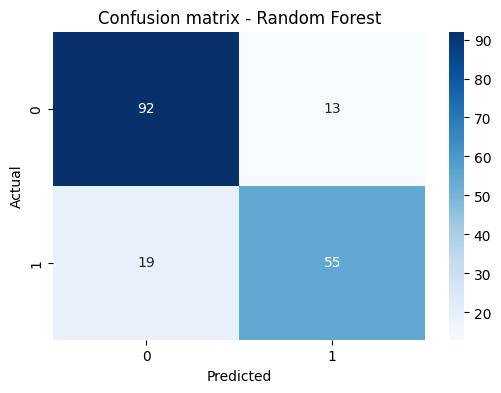

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
y_pred=rf.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 5: Best Model Analysis and Conclusion
### Best Model Analysis
Among the three Machine learning models evaluated,**Random** **Forest** **Classifier** was identified as the best-performing model based on its overall performance across **Accuracy**,**Precision**,**Recall** and **F1** **Score**.

Random Forest performed better because it is an ensemble learning algorithm that combines multiple decision trees to make predictions.This enables the model to capture complex relationships between features such as Sex,Pclass,Age,and Fare while reducing the risk of overfitting.As a result,it achieved better predictive performance compared to Logistic Regression and K-Nearest Neighbors.

### Confusion Matrix Analysis
A confusion matrix was generated to evaluate the classification performance of the random forest model.

Actual        Predicted 0       Predicted 1
0             92                13
1             19                55

The model correctly classified 92 passengers who did not survive and 55 pasengers who survived.It incorrectly classisfied 13 non-survivors as survivors and 19 survivors as non-survivors.The model performed slightly better at identifying passenger who did not survive than those who survived.However, the overall number of correct predictions was considerably higher than the number of incorrect predictions indicating good classification performance.

### Conclusion
The titanic dataset was successfully preprocessed by handling missing values,encoding variables and selecting relevant features.Correlation analysis identified Sex,Pclass and Fare as the most influential features affecting passenger survival.Three classification algorithms:Logistic Regression,Random Forest and KNN were trained and evaluated.Based on the evaluation metrics,Random Forest achieved the best best overall performance and was selected as the final model.This model demonstrates the effectiveness of ML techniques in predicting passenger survival using historical titanic data